In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CALLS_PARQUET = "../Data/Our Data/harmonized_calls_2021_2026.parquet"

In [4]:
df = pd.read_parquet(CALLS_PARQUET, engine='fastparquet')
df.head()

,agency,event_number,address,beat,call_source,priority,event_time,dispatch_time,arrival_time,incident_type_code,incident_type_desc,disposition_code,disposition_text,source_sheet
0,OP,LOP210101000001,E 15TH ST&35TH AV,23X,911 CALL,2,2021-01-01 00:00:43,2021-01-01 11:36:56,2021-01-01 11:49:11,415GS,415 GUNSHOTS,None,UNABLE TO LOCATE,2021
1,OP,LOP210101000002,E 23RD ST&FRUITVALE AV,21Y,DEFAULT - PHONE INIT,2,2021-01-01 00:00:51,2021-01-01 00:59:23,2021-01-01 01:00:33,415GS,415 GUNSHOTS,None,GONE ON ARRIVAL,2021
2,OP,LOP210101000003,6929 FOOTHILL BLVD,30Y,911 CALL,2,2021-01-01 00:00:54,NaT,NaT,415FC,415 FIRE CRACKERS,None,CANCELLED,2021
3,OP,LOP210101000004,104TH AV&WALNUT ST,32X,DEFAULT - PHONE INIT,2,2021-01-01 00:01:02,2021-01-01 00:39:31,2021-01-01 00:40:58,415GS,415 GUNSHOTS,None,UNABLE TO LOCATE,2021
4,OP,LOP210101000005,1564 76TH AV,30X,911 CALL,2,2021-01-01 00:01:24,NaT,NaT,415C,415 UNKNOWN,None,CANCELLED,2021


In [49]:
df['hour'] = df['event_time'].dt.hour
df['day_of_week'] = df['event_time'].dt.dayofweek
df['month'] = df['event_time'].dt.month
df['year'] = df['event_time'].dt.year
df['response_time'] = df['arrival_time'] - df['event_time']
df['response_time_min'] = df['response_time'].dt.total_seconds() / 60

In [58]:
# stats
stats = {
    'years': [],
    'counts': [],
    'medians': [],
    'means': [],
    'mins': [],
    'maxes': [],
    'zeroes': [],
    'two_hour_plus': []
}

for i, year in enumerate(set(df['year'])):
    stats['years'].append(year)
    stats['counts'].append(df[df['year'] == year]['response_time_min'].count())
    stats['medians'].append(df[df['year'] == year]['response_time_min'].median())
    stats['means'].append(df[df['year'] == year]['response_time_min'].mean())
    stats['mins'].append(df[df['year'] == year]['response_time_min'].min())
    stats['maxes'].append(df[df['year'] == year]['response_time_min'].max())
    stats['zeroes'].append(
        (df[df['year'] == year]['response_time_min'] == 0).count() / stats['counts'][i])
    stats['two_hour_plus'].append(
        (df[df['year'] == year]['response_time_min'] > 120).count() / stats['counts'][i])

print(stats)

{'years': [2021, 2022, 2023, 2024, 2025, 2026], 'counts': [np.int64(206973), np.int64(198984), np.int64(167039), np.int64(205755), np.int64(171664), np.int64(86303)], 'medians': [np.float64(11.333333333333334), np.float64(10.333333333333334), np.float64(0.016666666666666666), np.float64(6.968066666666667), np.float64(9.9473), np.float64(8.321333333333333)], 'means': [np.float64(177.46517887196234), np.float64(188.0217520001609), np.float64(248.84002059399305), np.float64(263.0980214188396), np.float64(151.60264292192886), np.float64(17.141419180484203)], 'mins': [np.float64(-1357.5), np.float64(-17.05), np.float64(0.0), np.float64(0.0), np.float64(-52.29855), np.float64(-44630.63305)], 'maxes': [np.float64(176660.26666666666), np.float64(97924.75), np.float64(268019.35), np.float64(298659.6757833333), np.float64(61778.683), np.float64(50132.40561666666)], 'zeroes': [np.float64(1.8665188212955313), np.float64(1.9601274474329595), np.float64(2.7261657457240527), np.float64(2.179320065125

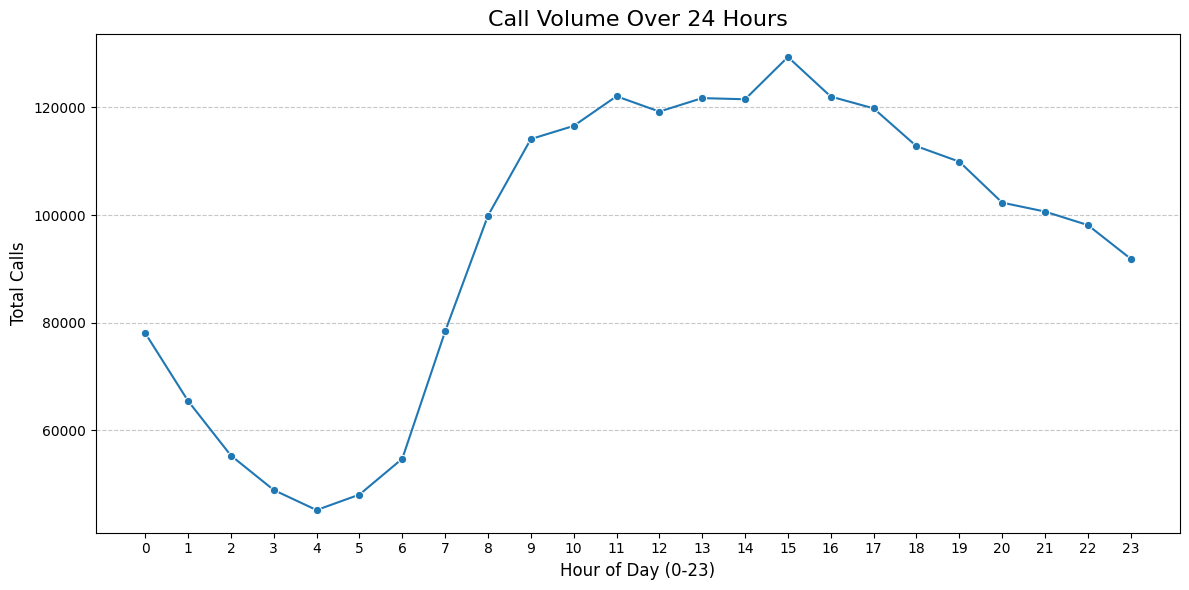

In [6]:
## Plot call volume (total)
hourly_vol_total = df.groupby('hour').size().reset_index(name='call_volume')
daily_vol_total = df.groupby('day_of_week').size().reset_index(name='call_volume')
monthly_vol_total = df.groupby('month').size().reset_index(name='call_volume')

# Plot hourly
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_vol_total, x='hour', y='call_volume', marker='o')

plt.title('Call Volume Over 24 Hours', fontsize=16)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Total Calls', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

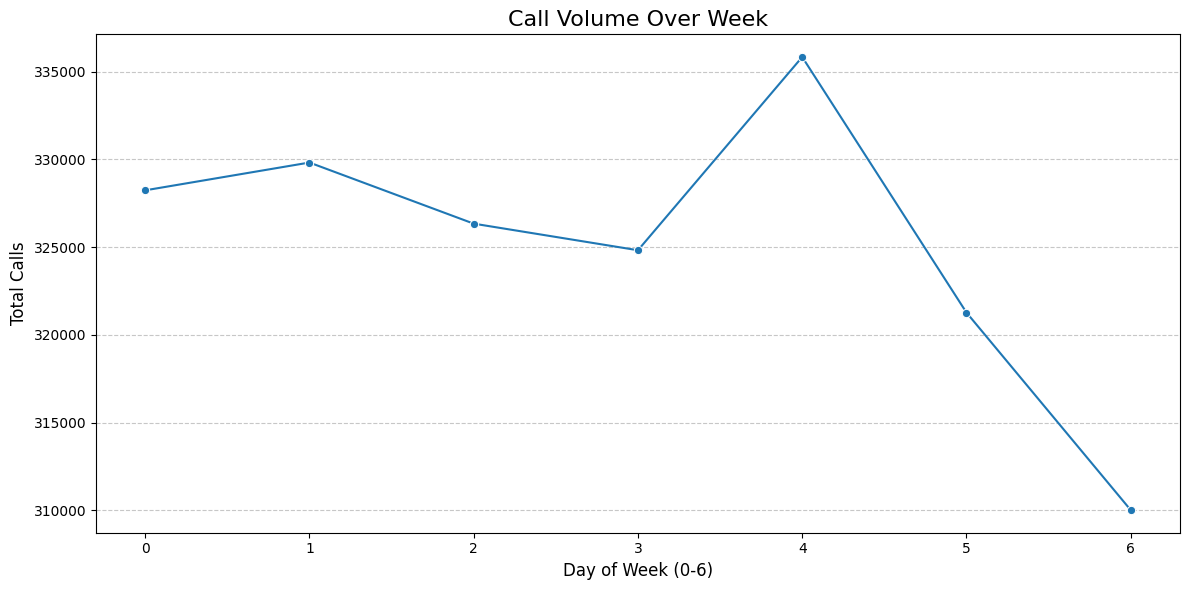

In [7]:
# Plot by day of week
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_vol_total, x='day_of_week', y='call_volume', marker='o')

plt.title('Call Volume Over Week', fontsize=16)
plt.xlabel('Day of Week (0-6)', fontsize=12)
plt.ylabel('Total Calls', fontsize=12)
plt.xticks(range(0, 7))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("../Outputs/volume_over_week.png", dpi=150, bbox_inches="tight")
plt.show()

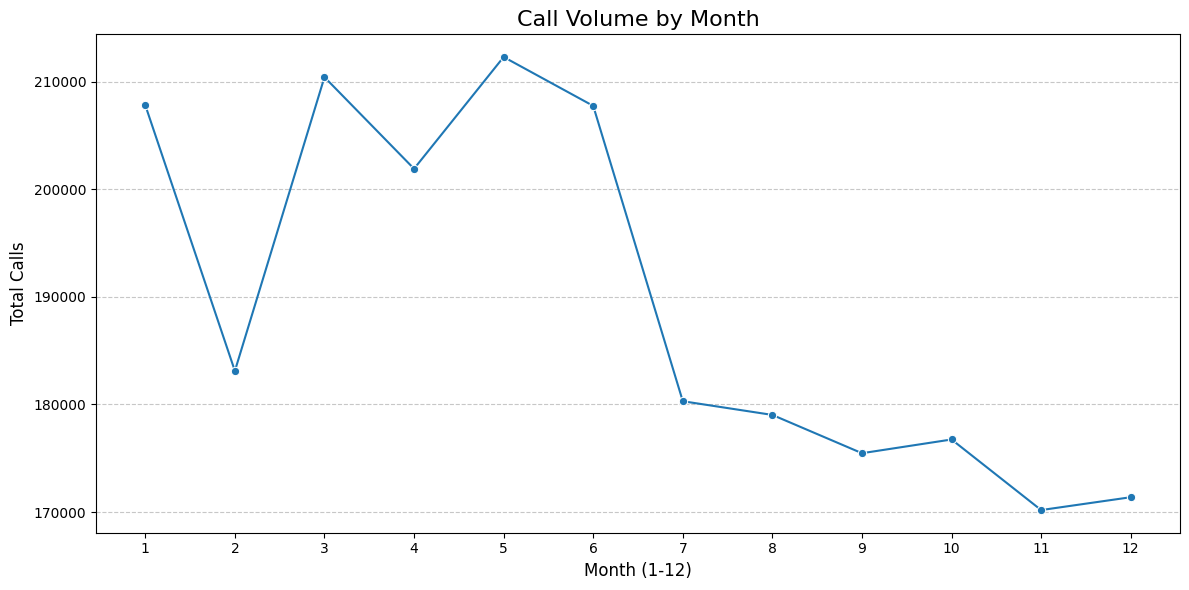

In [8]:
# Plot by month
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_vol_total, x='month', y='call_volume', marker='o')

plt.title('Call Volume by Month', fontsize=16)
plt.xlabel('Month (1-12)', fontsize=12)
plt.ylabel('Total Calls', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("../Outputs/volume_by_month.png", dpi=150, bbox_inches="tight")
plt.show()

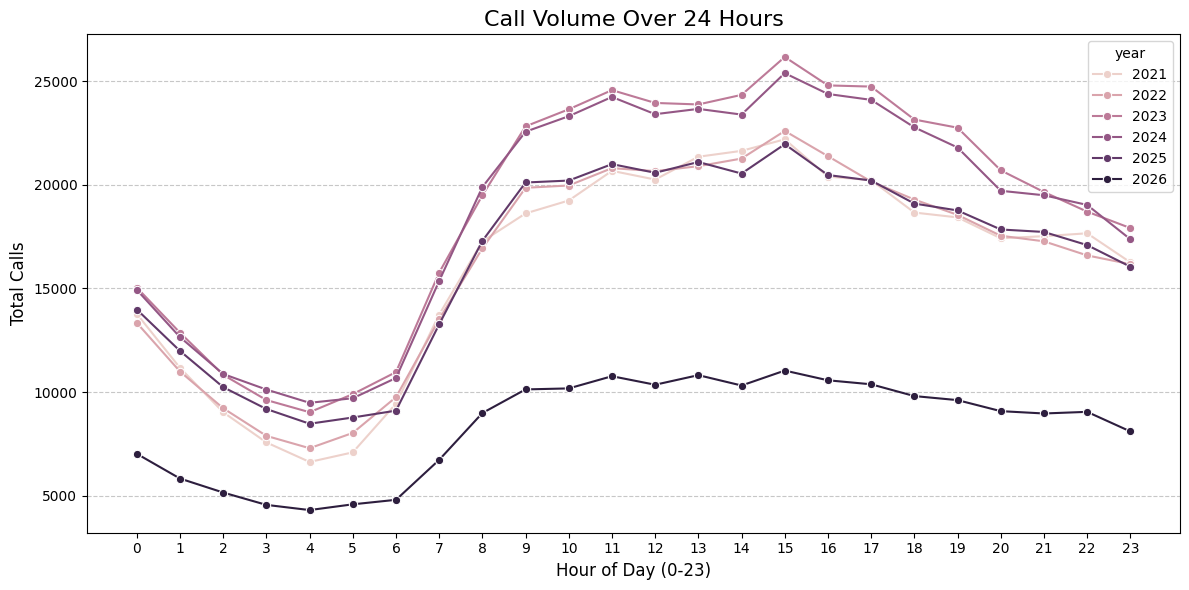

In [9]:
## Plot call volume (yearly)
hourly_vol_annual = df.groupby(['year', 'hour']).size().reset_index(name='call_volume')
daily_vol_annual = df.groupby(['year', 'day_of_week']).size().reset_index(name='call_volume')
monthly_vol_annual = df.groupby(['year', 'month']).size().reset_index(name='call_volume')

# Plot hourly
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_vol_annual, x='hour', y='call_volume', hue='year', marker='o')

plt.title('Call Volume Over 24 Hours', fontsize=16)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Total Calls', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

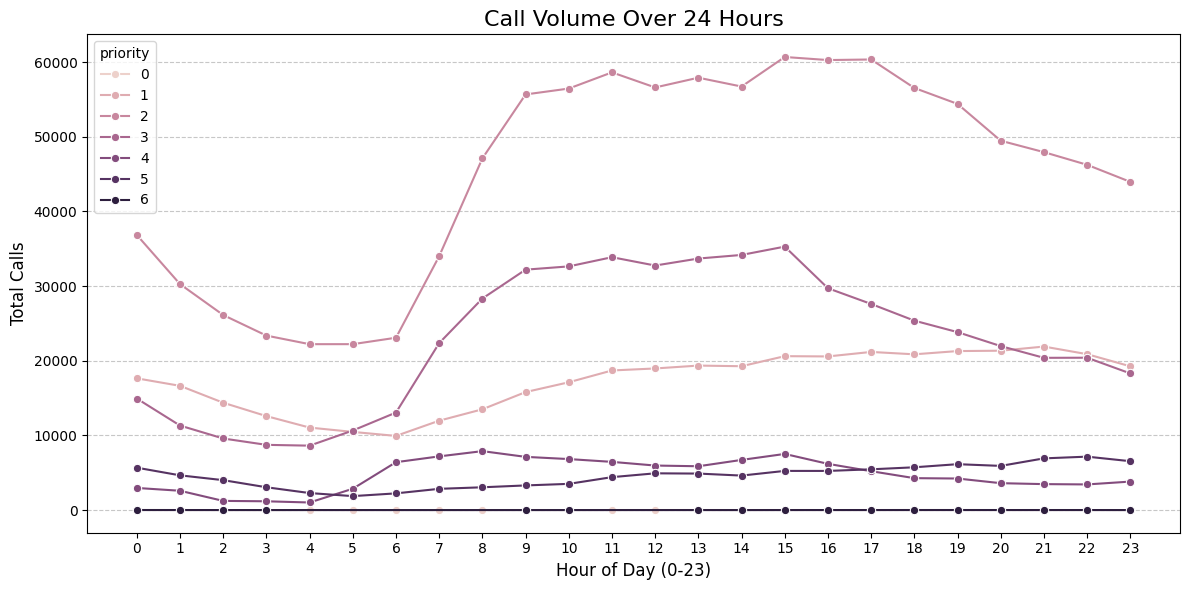

In [12]:
## Plot call volume (by priority)
df['priority'] = pd.to_numeric(df['priority'], errors='coerce').astype(int)
hourly_vol_prioritized = df.groupby(['priority', 'hour']).size().reset_index(name='call_volume')
daily_vol_prioritized = df.groupby(['priority', 'day_of_week']).size().reset_index(name='call_volume')
monthly_vol_prioritized = df.groupby(['priority', 'month']).size().reset_index(name='call_volume')

## Plot hourly by priority
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_vol_prioritized, x='hour', y='call_volume', hue='priority', marker='o')

plt.title('Call Volume Over 24 Hours', fontsize=16)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Total Calls', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("../Outputs/volume_by_priority.png", dpi=150, bbox_inches="tight")
plt.show()

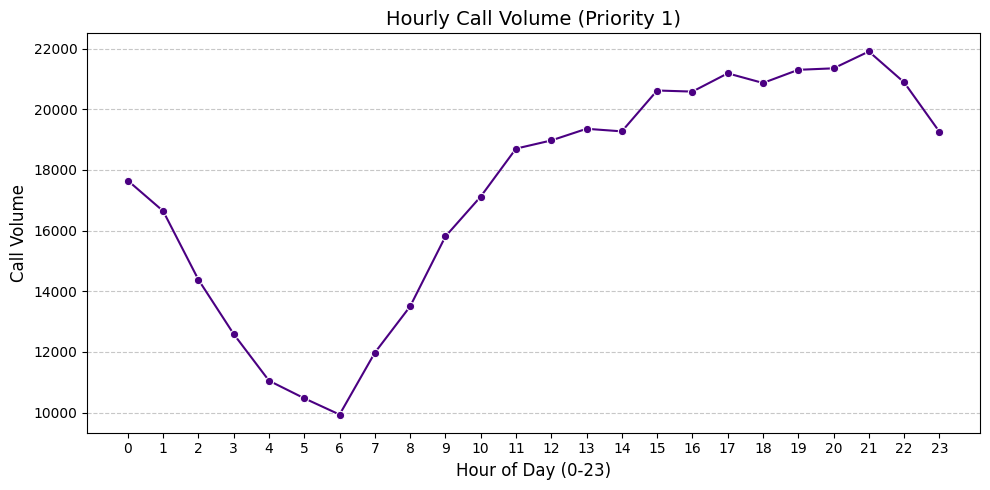

In [13]:
## Plot call volume (filtered by priority == 1)
p1_counts = (
    df[df['priority'] == 1]['hour']
    .value_counts()
    .sort_index()
    .reset_index(name='call_volume')
)

# Plot with Call Volume on the Y-axis
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=p1_counts, x='hour', y='call_volume', marker='o', color='indigo'
)

# Formatting
plt.title('Hourly Call Volume (Priority 1)', fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Call Volume', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("../Outputs/hourly_call_vol_p1.png", dpi=150, bbox_inches="tight")
plt.show()

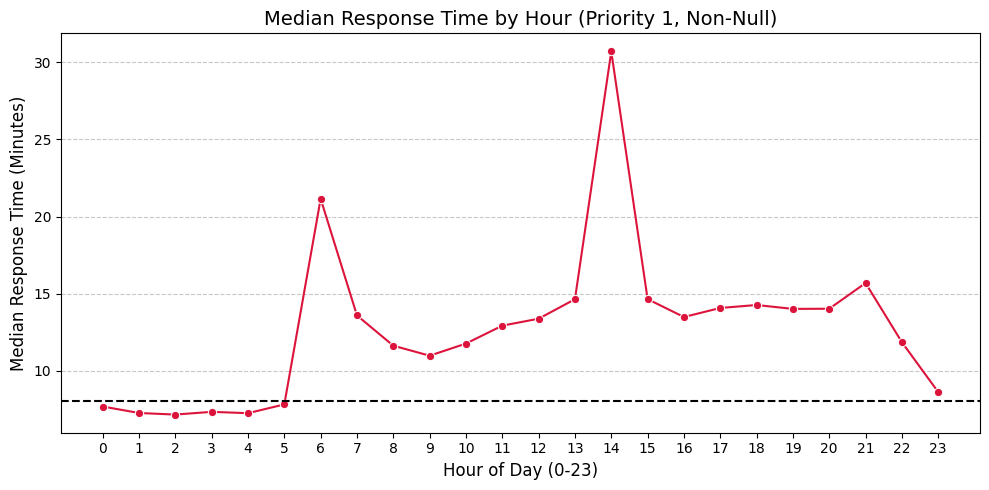

In [32]:
# 1. Filter for priority 1 and drop missing response_time values
p1_clean = df[
    (df['year'] >= 2025) & # 2021 data has some arrival times earlier than event times
    (df['priority'] == 1) & 
    (df['response_time'].notna()) & 
    (df['response_time'].dt.total_seconds() >= 0)
].copy()

# 2. Convert timedelta to minutes
p1_clean['response_time_min'] = p1_clean['response_time'].dt.total_seconds() / 60

# 3. Calculate median response time by hour
p1_hourly = (
    p1_clean.groupby('hour')['response_time_min']
    .median()
    .reset_index(name='median_response_time_min')
)

# 4. Plot
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=p1_hourly,
    x='hour',
    y='median_response_time_min',
    marker='o',
    color='crimson',
)
plt.axhline(y=8, color='black', linestyle='--', linewidth=1.5, label='8 Min SLA')

plt.title('Median Response Time by Hour (Priority 1, Non-Null)', fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Median Response Time (Minutes)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("../Outputs/p1_median_response_time_filtered.png", dpi=150, bbox_inches="tight")
plt.show()

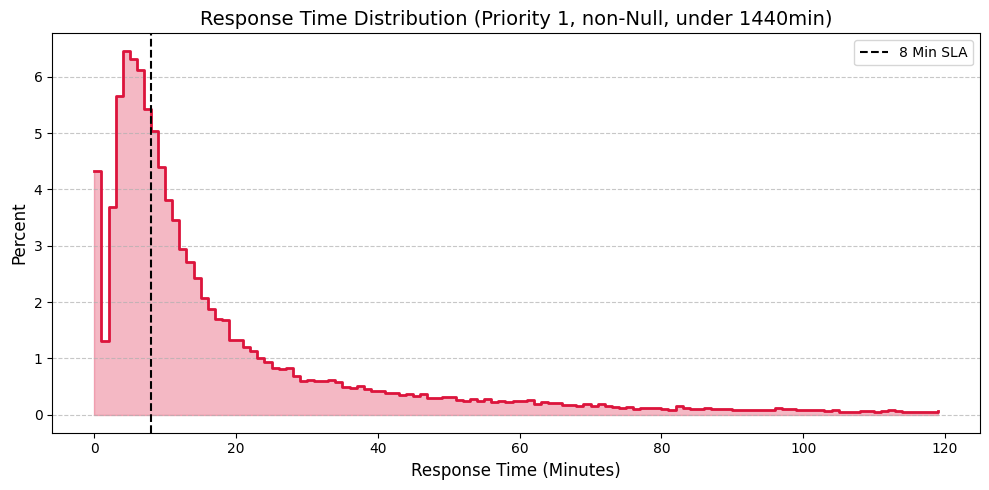

In [33]:
# 1. Compute 1-minute bins using NumPy C-extension (takes milliseconds)
max_min = 120
bins = np.arange(0, max_min + 1, 1)  # Bins: [0, 1, 2, ..., 60]
counts, bin_edges = np.histogram(p1_clean['response_time_min'], bins=bins)
pcts = (counts / counts.sum()) * 100

# 2. Plot step outline (extremely fast rendering)
plt.figure(figsize=(10, 5))
plt.step(bin_edges[:-1], pcts, where='post', color='crimson', linewidth=2)
plt.fill_between(bin_edges[:-1], pcts, step='post', color='crimson', alpha=0.3)

plt.axvline(x=8, color='black', linestyle='--', linewidth=1.5, label='8 Min SLA')
plt.title('Response Time Distribution (Priority 1, non-Null, under 1440min)', fontsize=14)
plt.xlabel('Response Time (Minutes)', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("../Outputs/p1_response_time_distribution_1440min_pct.png", dpi=150, bbox_inches="tight")
plt.show()

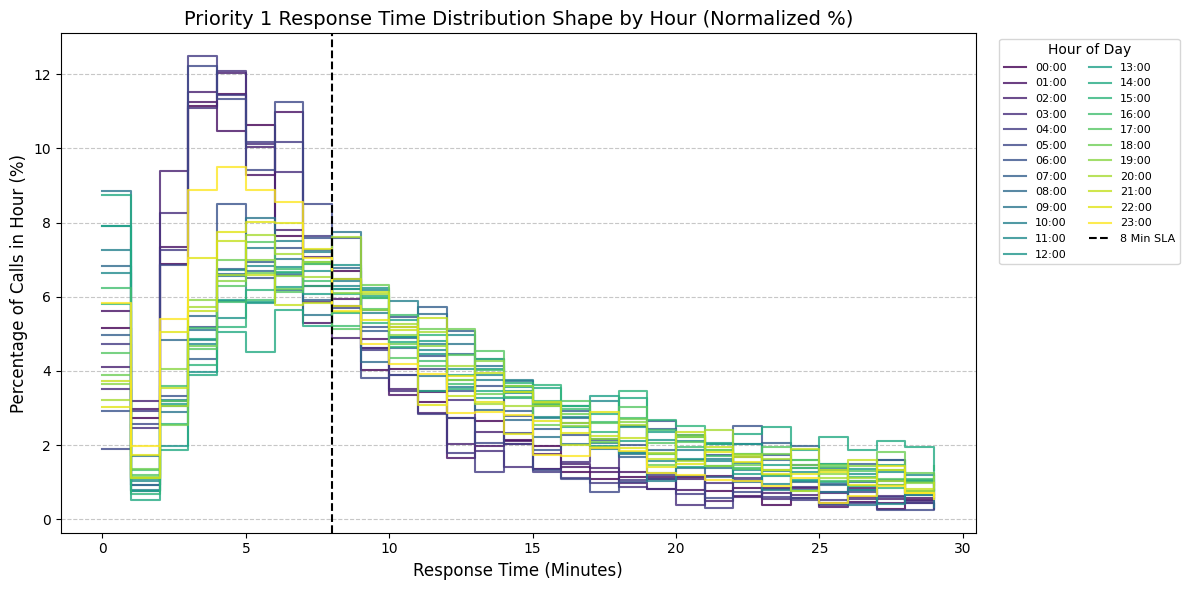

In [34]:
max_min = 30
bins = np.arange(0, max_min + 1, 1)

plt.figure(figsize=(12, 6))

# Map 24 distinct colors using a continuous colormap
cmap = plt.cm.viridis

# Loop through each hour (0 through 23)
for hour in range(24):
    hour_data = p1_clean[p1_clean["hour"] == hour]["response_time_min"]

    if len(hour_data) > 0:
        counts, bin_edges = np.histogram(hour_data, bins=bins)
        pcts = (
            counts / counts.sum()
        ) * 100  # Convert to percentage of hourly total

        plt.step(
            bin_edges[:-1],
            pcts,
            where="post",
            label=f"{hour:02d}:00",
            linewidth=1.5,
            color=cmap(hour / 23.0),
            alpha=0.8,
        )

plt.axvline(x=8, color="black", linestyle="--", linewidth=1.5, label="8 Min SLA")
plt.title(
    "Priority 1 Response Time Distribution Shape by Hour (Normalized %)",
    fontsize=14,
)
plt.xlabel("Response Time (Minutes)", fontsize=12)
plt.ylabel("Percentage of Calls in Hour (%)", fontsize=12)

# Move legend outside the plot area to keep chart clean
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    ncol=2,
    fontsize=8,
    title="Hour of Day",
)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig(
    "../Outputs/p1_response_time_distribution_by_hour.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [35]:
p1_clean.head(10)
p1_clean['response_time_min'].mean() # 457.9084993719566
p1_clean['response_time_min'].median() # 10.833333333333334
p1_clean['response_time_min'].min() # 0.0
p1_clean['response_time_min'].max() # 142554.9685

pct_zero = (p1_clean['response_time_min'] == 0).mean() * 100
print(f"{pct_zero:.2f}% of priority 1 calls have a 0-minute response time.")

pct_24h = (p1_clean['response_time_min'] >= 1440).mean() * 100
print(f"{pct_24h:.2f}% of priority 1 calls have a response time more than 24 hours (1440 min).")

3.69% of priority 1 calls have a 0-minute response time.
5.89% of priority 1 calls have a response time more than 24 hours (1440 min).


In [36]:
# Priority 1 calls by Beat
p1_beat = p1_clean.copy()
beat_median_response = p1_beat.groupby('beat')['response_time_min'].median().reset_index(name='median_response_time_min')
beat_volume = p1_beat.groupby('beat').size().reset_index(name='call_volume')

/var/folders/x4/b9ytdy8d4_n7mkvbslm7rq5c0000gn/T/ipykernel_92915/1940207004.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


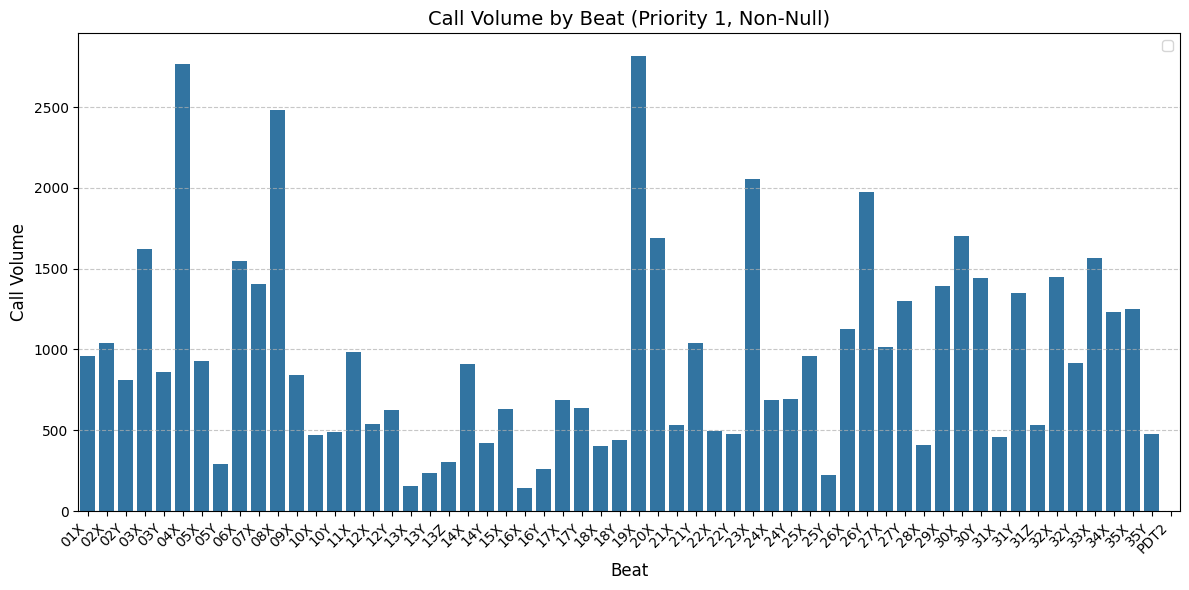

In [37]:
# Plot priority 1 call volume by beat

plt.figure(figsize=(12, 6))
sns.barplot(
    data=beat_volume,
    x='beat',
    y='call_volume'
)

plt.title('Call Volume by Beat (Priority 1, Non-Null)', fontsize=14)
plt.xlabel('Beat', fontsize=12)
plt.ylabel('Call Volume', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotates location labels if text is long
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.savefig("../Outputs/p1_volume_by_beat.png", dpi=150, bbox_inches="tight")
plt.show()

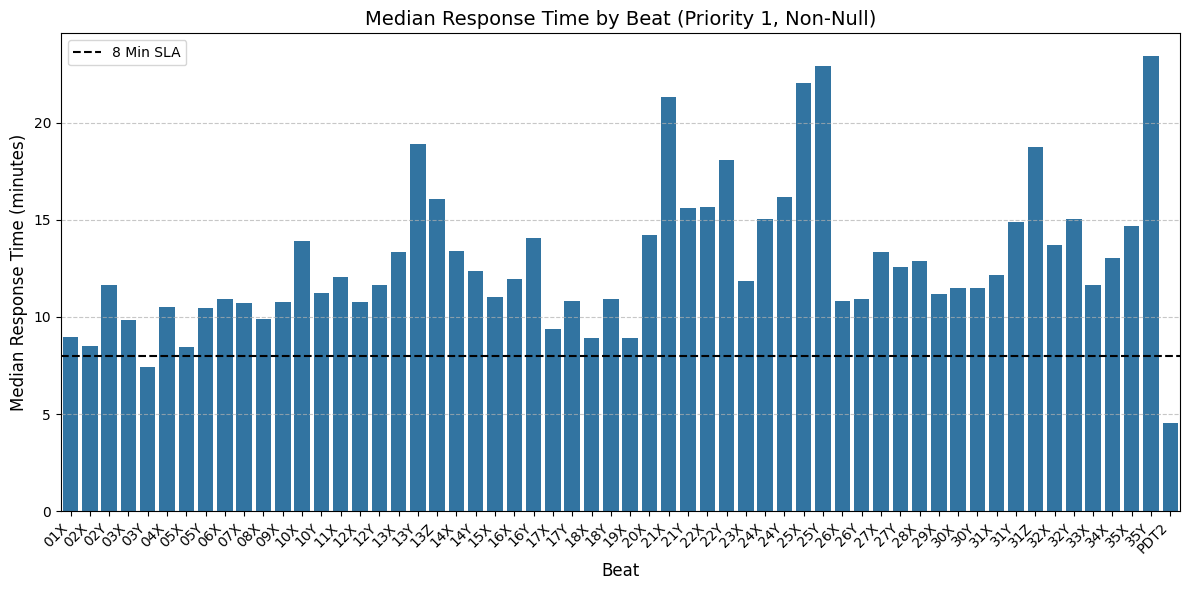

In [38]:
# Plot priority 1 median response time by beat

plt.figure(figsize=(12, 6))
sns.barplot(
    data=beat_median_response,
    x='beat',
    y='median_response_time_min'
)

# Add horizontal 8-minute SLA line if needed
plt.axhline(y=8, color='black', linestyle='--', label='8 Min SLA')

plt.title('Median Response Time by Beat (Priority 1, Non-Null)', fontsize=14)
plt.xlabel('Beat', fontsize=12)
plt.ylabel('Median Response Time (minutes)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotates location labels if text is long
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.savefig("../Outputs/p1_median_response_time_by_beat.png", dpi=150, bbox_inches="tight")
plt.show()